# Chapter 4: Physical Platforms — Which Hardware for Which QEC?

## Overview

Chapters 1–3 established *what* errors are, *how* QEC codes correct them, and *that*
the pipeline works. This chapter asks the most practically important question:

> **Which quantum computing platform should use which QEC code, and why?**

The answer is not universal. Each hardware platform has a distinct noise fingerprint —
a characteristic pattern of dominant error types, magnitudes, and correlations — that
makes certain QEC codes natural fits and others impractical.

This chapter covers five major platforms:

| Section | Platform | Key players | QEC frontier (2025) |
|---|---|---|---|
| 4.1 | DiVincenzo criteria | — | Universal framework |
| 4.2 | Superconducting qubits | IBM, Google | Surface code, qLDPC |
| 4.3 | Trapped ions | Quantinuum, IonQ | Color codes, qLDPC |
| 4.4 | Neutral atoms | QuEra, Pasqal | Erasure codes, transversal |
| 4.5 | Silicon spin qubits | Intel, Imec, UNSW | Surface code (path) |
| 4.6 | Photonic qubits | PsiQuantum, Xanadu | GKP, cluster states |
| 4.7 | Quantitative comparison | All | Decision guide |

**Prerequisites:** Chapters 1–3. Understanding of error types ($X$, $Z$, $Y$,
decoherence, erasure) and the $[[n,k,d]]$ notation.

**Libraries:**
```python
numpy, matplotlib, scipy
```

---

**Key references for this chapter:**

| # | Reference |
|---|---|
| [1] | DiVincenzo, D. P. The physical implementation of quantum computation. *Fortschr. Phys.* **48**, 771 (2000). |
| [2] | Krantz, P. et al. A quantum engineer's guide to superconducting qubits. *Appl. Phys. Rev.* **6**, 021318 (2019). |
| [3] | Bruzewicz, C. D. et al. Trapped-ion quantum computing: Progress and challenges. *Appl. Phys. Rev.* **6**, 021314 (2019). |
| [4] | Evered, S. J. et al. High-fidelity parallel entangling gates on a neutral-atom quantum computer. *Nature* **622**, 268 (2023). |
| [5] | Bluvstein, D. et al. A fault-tolerant neutral-atom architecture for universal quantum computation. *Nature* (2025). DOI:10.1038/s41586-025-09848-5 |
| [6] | Tanttu, T. et al. Assessment of the errors of high-fidelity two-qubit gates in silicon quantum dots. *Nat. Phys.* **20**, 1804 (2024). |
| [7] | Bourassa, J. E. et al. Blueprint for a scalable photonic fault-tolerant quantum computer. *Quantum* **5**, 392 (2021). |
| [8] | Fowler, A. M. et al. Surface codes: Towards practical large-scale quantum computation. *Phys. Rev. A* **86**, 032324 (2012). |
| [9] | Gottesman, D., Kitaev, A. & Preskill, J. Encoding a qubit in an oscillator. *Phys. Rev. A* **64**, 012310 (2001). |
| [10] | Google Quantum AI. Quantum error correction below the surface code threshold. *Nature* **614**, 676 (2023). |
| [11] | Acharya et al. (Google). Quantum error correction above the surface code threshold. *Nature* **638**, 920 (2025). |
| [12] | Bravyi, S. et al. High-threshold and low-overhead fault-tolerant quantum memory. *Nature* **627**, 778 (2024). (IBM bivariate bicycle code) |
| [13] | Noiri, A. et al. Fast universal quantum gate above the fault-tolerance threshold in silicon. *Nature* **601**, 338 (2022). |
| [14] | Campagne-Ibarcq, P. et al. Quantum error correction of a qubit encoded in grid states of an oscillator. *Nature* **584**, 368 (2020). |
| [15] | Riverlane. *The Quantum Error Correction Report 2025*. https://www.riverlane.com |

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit
import math

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

# ── Platform colour palette ───────────────────────────────────────────────────
PLATFORM_COLORS = {
    "Superconducting": "#5b9bd5",
    "Trapped ion":     "#e07b54",
    "Neutral atom":    "#70ad47",
    "Silicon spin":    "#ffc000",
    "Photonic":        "#9b59b6",
}

print("Chapter 4: Physical Platforms — ready.")
print(f"Platforms: {list(PLATFORM_COLORS.keys())}")

Chapter 4: Physical Platforms — ready.
Platforms: ['Superconducting', 'Trapped ion', 'Neutral atom', 'Silicon spin', 'Photonic']


---
## 4.1 The DiVincenzo Criteria: A Universal Scorecard

In 2000, David DiVincenzo [1] formulated five necessary conditions any physical system
must satisfy to serve as a quantum computer. These criteria remain the standard
framework for evaluating hardware platforms.

### The five criteria

| # | Criterion | What it requires |
|---|---|---|
| D1 | **Scalable qubits** | A well-defined, extendable set of qubits |
| D2 | **Initialization** | Ability to prepare a fiducial state (e.g. $\|0\rangle^{\otimes n}$) |
| D3 | **Long coherence** | Decoherence times much longer than gate times: $T_{\rm coh} \gg t_{\rm gate}$ |
| D4 | **Universal gates** | A complete gate set (e.g. single-qubit rotations + CNOT) |
| D5 | **Measurement** | Qubit-specific, high-fidelity readout |

DiVincenzo also added two criteria for quantum communication:
- **D6:** Ability to convert stationary and flying qubits
- **D7:** Ability to faithfully transmit flying qubits

### The QEC extension

For fault-tolerant quantum computing, D3 must be made more precise. The relevant
figure of merit is not just $T_{\rm coh}/t_{\rm gate}$ in isolation, but the
**physical error rate** $p$ relative to the **fault-tolerance threshold** $p_{\rm th}$
of the target QEC code:

$$p \ll p_{\rm th} \quad \Longrightarrow \quad \text{error suppression is exponential in } d$$

$$p > p_{\rm th} \quad \Longrightarrow \quad \text{adding more qubits makes things worse}$$

The threshold depends on both the code and the noise model:

| QEC code | $p_{\rm th}$ (depolarizing) | $p_{\rm th}$ (biased $Z$) |
|---|---|---|
| Surface code | $\approx 1\%$ | $\approx 10\%$ (biased-noise variant) |
| Color code | $\approx 0.8\%$ | — |
| qLDPC (bicycle) | $\approx 0.5$–$1\%$ | — |
| Repetition code | $\approx 50\%$ | $\approx 50\%$ ($Z$-only noise) |

The platform sections below evaluate each technology against all five DiVincenzo
criteria and map its noise profile to the most appropriate QEC strategy.

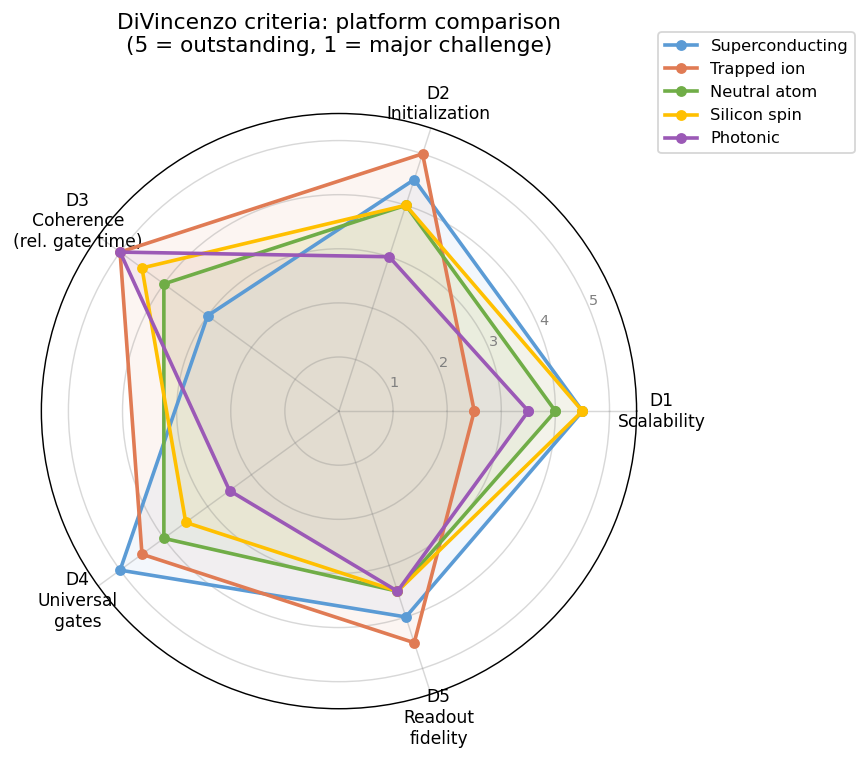

Score annotations:
            Platform | D1(Scale) | D2(Init) | D3(Coh) | D4(Gates) | D5(Readout) | Sum
---------------------------------------------------------------------------
     Superconducting |   4.5    4.5    3.0    5.0    4.0 |  21.0
         Trapped ion |   2.5    5.0    5.0    4.5    4.5 |  21.5
        Neutral atom |   4.0    4.0    4.0    4.0    3.5 |  19.5
        Silicon spin |   4.5    4.0    4.5    3.5    3.5 |  20.0
            Photonic |   3.5    3.0    5.0    2.5    3.5 |  17.5


In [10]:
# ── DiVincenzo score card (qualitative 1–5 per criterion) ─────────────────────
# Scores based on 2024–2025 state of the art across published benchmarks.
# 5 = outstanding, 1 = major challenge.

criteria_labels = [
    'D1\nScalability', 'D2\nInitialization', 'D3\nCoherence\n(rel. gate time)',
    'D4\nUniversal\ngates', 'D5\nReadout\nfidelity'
]

platform_scores = {
    #                    D1   D2   D3   D4   D5
    "Superconducting":  [4.5, 4.5, 3.0, 5.0, 4.0],
    "Trapped ion":      [2.5, 5.0, 5.0, 4.5, 4.5],
    "Neutral atom":     [4.0, 4.0, 4.0, 4.0, 3.5],
    "Silicon spin":     [4.5, 4.0, 4.5, 3.5, 3.5],
    "Photonic":         [3.5, 3.0, 5.0, 2.5, 3.5],
}

# ── Radar chart ───────────────────────────────────────────────────────────────
N = len(criteria_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for platform, scores in platform_scores.items():
    vals = scores + scores[:1]
    col  = PLATFORM_COLORS[platform]
    ax.plot(angles, vals, '-o', color=col, linewidth=2, markersize=5, label=platform)
    ax.fill(angles, vals, color=col, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria_labels, size=9.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], size=8, color='gray')
ax.set_ylim(0, 5.5)
ax.set_title("DiVincenzo criteria: platform comparison\n(5 = outstanding, 1 = major challenge)",
             pad=18, size=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.15), fontsize=9)
ax.grid(color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

print("Score annotations:")
print(f"{'Platform':>20} | D1(Scale) | D2(Init) | D3(Coh) | D4(Gates) | D5(Readout) | Sum")
print("-"*75)
for platform, scores in platform_scores.items():
    print(f"{platform:>20} | {'  '.join(f'{s:5.1f}' for s in scores)} | {sum(scores):5.1f}")

---
## 4.2 Superconducting Qubits

### 4.2.1 Physical mechanism

Superconducting qubits are microwave-frequency LC oscillators made nonlinear by a
**Josephson junction** — a nanoscale tunnel barrier between two superconducting
electrodes. The nonlinearity lifts the degeneracy of energy levels, making the
lowest two states ($|0\rangle$, $|1\rangle$) addressable individually.

The dominant design today is the **transmon**: a charge-insensitive variant that
dramatically reduces sensitivity to offset-charge noise at the cost of reduced
anharmonicity (~200–300 MHz). Newer designs include the **fluxonium** (exponentially
suppressed charge noise, lower frequency, long $T_1 \sim 1$ ms achievable) and
**Majorana qubits** (Microsoft; inherent topological protection, not yet proven at scale).

**Operating conditions:** 15 mK in a dilution refrigerator. Gates applied via
microwave pulses through coaxial lines; readout via dispersive coupling to a
transmission-line resonator.

### 4.2.2 Noise profile

| Error source | Physical origin | Typical rate |
|---|---|---|
| $T_1$ relaxation | Two-level systems (TLS) at oxide/interface, Purcell decay | $1/T_1 \sim 10^{-5}$–$10^{-4}$ per gate |
| $T_2$ dephasing | Charge noise, flux noise, photon-number fluctuations | $1/T_2 \sim 10^{-4}$–$10^{-3}$ per gate |
| Two-qubit gate | ZZ crosstalk, leakage to $\|2\rangle$, control errors | $10^{-3}$–$10^{-2}$ |
| Readout | Dispersive readout SNR, photon-induced dephasing | $10^{-3}$–$10^{-2}$ |

**Noise bias:** $Z$ errors (dephasing) typically dominate over $X$ errors.
This means biased-noise QEC codes can offer a significant advantage.

### 4.2.3 State of the art (2025)

IBM's Heron r3 processor achieved 99.75% two-qubit gate fidelity (median CZ) in 2025. 
Google's Willow chip (105 qubits) was the first to demonstrate that the surface code reduces errors exponentially, operating below threshold. 
IBM's Nighthawk processor (2025) aims for 120 qubits with tunable couplers supporting up to 5,000 two-qubit gates, with a path to 15,000 gates by 2027. 

Coherence times: $T_1 \sim 100$–500 µs (transmon); up to 1 ms with tantalum-film
or fluxonium devices. Gate times: $\sim$20–50 ns (single-qubit), $\sim$100–400 ns
(two-qubit CZ/cross-resonance).

### 4.2.4 QEC strategy

**Primary code: Surface code** $[[d^2, 1, d]]$

- Threshold $\approx 1\%$ under depolarizing noise — among the highest of any code.
- Only nearest-neighbour 2D interactions required — natural match for planar chip layout.
- Google demonstrated below-threshold scaling with the surface code (2023, 2025) [10, 11].

**Emerging: qLDPC codes (bivariate bicycle, Gross code)**

- IBM's 2024 bivariate bicycle code [12] demonstrated quantum memory as good as
  the surface code but with ~$4\times$ fewer physical qubits per logical qubit.
- The Gross code (a higher-rate qLDPC) requires non-local connectivity — motivating
  IBM's $c$-couplers (long-range connections within a chip) in the Loon/Nighthawk roadmap.
- IBM's target: fault-tolerant computation with 100 million gates on 200 logical qubits
  by 2029 (Starling system).

**Key challenge:** The surface code requires $\sim$1,000 physical qubits per logical
qubit at practical distances ($d \sim 15$–20). A 200-logical-qubit machine needs
$\sim$200,000 physical qubits with per-gate error rates below $\sim 0.1\%$.

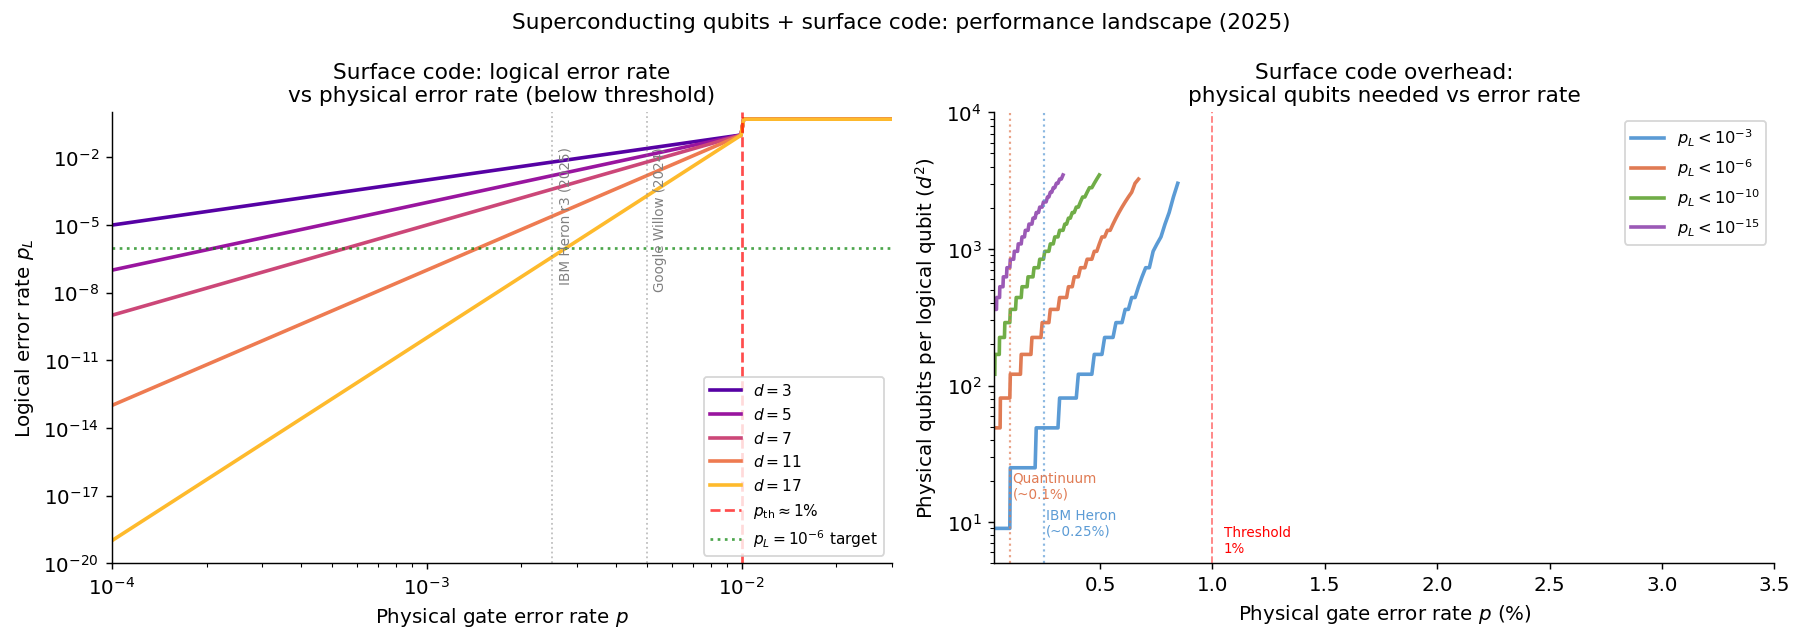

Key numbers (superconducting + surface code):
  p = 0.10%: need d=11 (121 phys. qubits) for p_L < 1e-6
  p = 0.25%: need d=17 (289 phys. qubits) for p_L < 1e-6
  p = 0.50%: need d=33 (1089 phys. qubits) for p_L < 1e-6
  p = 1.00%: above threshold or d>50 needed


In [11]:
# ── Surface code logical error rate vs physical error rate ────────────────────
# Analytical model: p_L ≈ A*(p/p_th)^((d+1)/2)

def logical_error_rate(p, d, p_th=0.01, A=0.1):
    """Analytical surface code logical error rate below threshold."""
    if p >= p_th:
        return 0.5   # above threshold: useless
    return A * (p / p_th) ** ((d + 1) / 2)

p_vals  = np.logspace(-4, -1.5, 300)   # 1e-4 to ~3%
distances = [3, 5, 7, 11, 17]
colors_d  = plt.cm.plasma(np.linspace(0.15, 0.85, len(distances)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: p_L vs p for different distances
ax1 = axes[0]
for d, col in zip(distances, colors_d):
    pL = [logical_error_rate(p, d) for p in p_vals]
    ax1.loglog(p_vals, pL, linewidth=2, color=col, label=f'$d = {d}$')

# Shade the "useful" operating region (p_L < 10^-6, below threshold)
ax1.axvline(0.01, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label='$p_{\\rm th} \\approx 1\\%$')
ax1.axhline(1e-6, color='green', linestyle=':', linewidth=1.5, alpha=0.7,
            label='$p_L = 10^{-6}$ target')

# Mark current IBM/Google gate fidelities
current_2q = {'IBM Heron r3 (2025)': 1-0.9975, 'Google Willow (2024)': 0.005}
for label, p_err in current_2q.items():
    ax1.axvline(p_err, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax1.text(p_err*1.05, 3e-2, label, fontsize=7.5, color='gray', rotation=90,
             va='top')

ax1.set_xlabel('Physical gate error rate $p$')
ax1.set_ylabel('Logical error rate $p_L$')
ax1.set_title('Surface code: logical error rate\nvs physical error rate (below threshold)')
ax1.legend(fontsize=8.5, loc='lower right')
ax1.set_xlim(1e-4, 3e-2)
ax1.set_ylim(1e-20, 1)

# Right: qubit overhead vs physical error rate
ax2 = axes[1]
target_pL  = [1e-3, 1e-6, 1e-10, 1e-15]
target_cols = ['#5b9bd5', '#e07b54', '#70ad47', '#9b59b6']

# Data range: p from 0.03% to 3% (logspace in fractions, converted to %)
p_phys = np.logspace(-3.5, -1.5, 200)

for pL_target, col in zip(target_pL, target_cols):
    qubits_needed = []
    for p in p_phys:
        if p >= 0.01:
            qubits_needed.append(np.nan)
            continue
        found = False
        for d_try in range(3, 60, 2):
            if logical_error_rate(p, d_try) < pL_target:
                qubits_needed.append(d_try**2)
                found = True
                break
        if not found:
            qubits_needed.append(np.nan)

    ax2.semilogy(p_phys * 100, qubits_needed, linewidth=2, color=col,
                 label=f'$p_L < 10^{{{int(np.log10(pL_target))}}}$')

ax2.set_xlabel('Physical gate error rate $p$ (%)')
ax2.set_ylabel('Physical qubits per logical qubit ($d^2$)')
ax2.set_title('Surface code overhead:\nphysical qubits needed vs error rate')
ax2.legend(fontsize=9)

# Annotate current device error rates
ax2.axvline(0.25, color=PLATFORM_COLORS['Superconducting'],
            linestyle=':', linewidth=1.2, alpha=0.7)
ax2.text(0.26, 8, 'IBM Heron\n(~0.25%)', fontsize=7.5,
         color=PLATFORM_COLORS['Superconducting'])
ax2.axvline(0.1, color=PLATFORM_COLORS['Trapped ion'],
            linestyle=':', linewidth=1.2, alpha=0.7)
ax2.text(0.11, 15, 'Quantinuum\n(~0.1%)', fontsize=7.5,
         color=PLATFORM_COLORS['Trapped ion'])

# Fix: xlim must start > 0 for semilogy; use the actual data range
ax2.set_xlim(0.03, 3.5)
ax2.set_ylim(5, 1e4)
ax2.axvline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.text(1.05, 6, 'Threshold\n1%', fontsize=7.5, color='red')

plt.suptitle("Superconducting qubits + surface code: performance landscape (2025)",
             fontsize=12)
plt.tight_layout()
plt.show()

print("Key numbers (superconducting + surface code):")
for p_eff in [0.001, 0.0025, 0.005, 0.01]:
    print(f"  p = {p_eff*100:.2f}%: ", end='')
    for d_try in range(3, 50, 2):
        if logical_error_rate(p_eff, d_try) < 1e-6:
            print(f"need d={d_try} ({d_try**2} phys. qubits) for p_L < 1e-6")
            break
    else:
        print("above threshold or d>50 needed")

---
## 4.3 Trapped-Ion Qubits

### 4.3.1 Physical mechanism

Trapped-ion qubits encode quantum information in the **internal electronic states** of
individual atomic ions held in an electromagnetic (Paul or Penning) trap.
Common species: $^{171}$Yb$^+$, $^{133}$Ba$^+$ (Quantinuum/IonQ), $^{40}$Ca$^+$ (academic).

Qubits are defined on either:
- **Hyperfine states** (frequency $\sim$ GHz): $T_1 \gg 1$ hour (practically infinite)
- **Optical transitions** (frequency $\sim$ THz): shorter $T_1$, higher-precision clocks

Gates are applied using laser pulses (or microwave + magnetic field gradients).
Two-qubit gates exploit the **Mølmer–Sørensen (MS) interaction** via shared motional
(phonon) modes of the ion chain as a quantum bus — this inherently provides all-to-all
connectivity within a chain.

**Quantum charge-coupled device (QCCD):** Multi-zone trap chips where ions are
shuttled between gate zones, memory zones, and readout zones. Enables large qubit
counts without degrading fidelity.

### 4.3.2 Noise profile

| Error source | Physical origin | Typical rate |
|---|---|---|
| $T_2$ dephasing | Magnetic field fluctuations, laser phase noise | $10^{-5}$–$10^{-4}$ per gate |
| Two-qubit gate | Motional heating, off-resonant excitation, optical errors | $10^{-4}$–$10^{-3}$ |
| SPAM | State-dependent fluorescence fidelity | $10^{-3}$–$10^{-4}$ |
| Ion loss | Background gas collisions, chain re-ordering | Rare but uncorrectable by Pauli codes |
| Crosstalk | Off-resonant sideband excitation | Low (can be suppressed by frequency separation) |

**Noise character:** $Z$-dominated (laser phase noise, magnetic fluctuations).
$T_1$ is effectively infinite — relaxation is not a practical concern for hyperfine qubits.

### 4.3.3 State of the art (2025)

Quantinuum's H-Series became the first to achieve "three nines" — 99.9% — two-qubit gate fidelity across all qubit pairs in a production device. 

IonQ demonstrated two-qubit gate fidelity exceeding 99.99% using a novel "smooth gate" technique without ground-state cooling. 

Oxford Ionics (now part of IonQ) achieved single-qubit gate errors at the $1.5 \times 10^{-7}$ level — the first demonstration of "seven nines" fidelity for any qubit. 

Coherence: $T_2 \sim 1$–10 s (with dynamical decoupling). Gate times: $\sim$1–100 µs
(2–3 orders of magnitude slower than superconducting). This is the key scalability
bottleneck: a 1,000-gate circuit takes $\sim$10–100 ms, not $\sim$0.05 ms.

### 4.3.4 QEC strategy

**Primary codes: Color codes and high-rate qLDPC**

- **Color codes** $[[7,1,3]]$, $[[15,1,3]]$: Transversal Clifford gates — a significant
  advantage since all logical gates can be applied without magic state distillation
  for the Clifford group. All-to-all connectivity makes non-local CSS codes feasible.
- **Brings' code (qLDPC):** Quantinuum's Helios system demonstrated real-time QEC
  using Brings' code with NVIDIA GPU-accelerated BP-OSD decoding.
- Very high physical fidelity ($p \sim 10^{-3}$–$10^{-4}$) means small code distances
  suffice: $d = 3$ gives $p_L \sim 10^{-7}$ at $p = 0.1\%$, eliminating much of the
  overhead that plagues superconducting systems.

**Key advantage over superconducting:** At the same physical error rate, trapped ions
need far fewer physical qubits per logical qubit — potentially 13:1 vs 500–1000:1 [7].

**Key disadvantage:** Gate speed. A superconducting chip can attempt $\sim 10^6$ gates
per second; a trapped-ion chain $\sim 10^3$–$10^4$. This limits achievable circuit depth
before decoherence within the total computation time.

<>:18: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
<>:18: SyntaxWarning: invalid escape sequence '\%'
<>:20: SyntaxWarning: invalid escape sequence '\%'
C:\Users\tan\AppData\Local\Temp\ipykernel_16772\2930269915.py:18: SyntaxWarning: invalid escape sequence '\%'
  ax1.text(2015.8, 99.91, '$99.9\%$ — surface code\npractical threshold', fontsize=8, color='gray')
C:\Users\tan\AppData\Local\Temp\ipykernel_16772\2930269915.py:20: SyntaxWarning: invalid escape sequence '\%'
  ax1.text(2015.8, 100.0, '$99.99\%$ — ultra-low overhead QEC', fontsize=8, color='green')


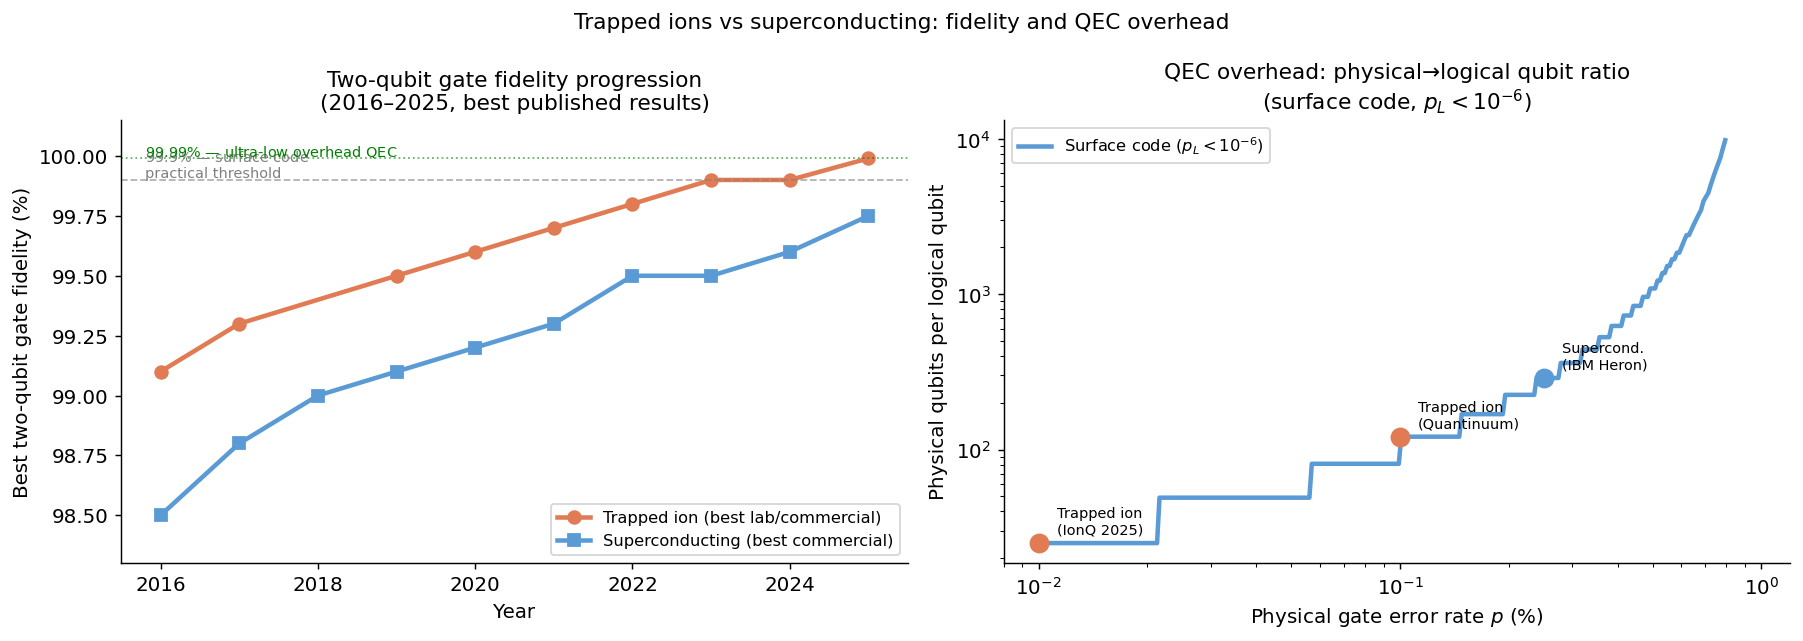

Overhead at current best fidelities (surface code, p_L < 1e-6):
  IBM Heron (p=0.25%)           : d=17, 289 physical qubits per logical
  Quantinuum (p=0.1%)           : d=11, 121 physical qubits per logical
  IonQ lab (p=0.01%)            : d=5, 25 physical qubits per logical


In [4]:
# ── Historical fidelity progression: trapped ion vs superconducting ───────────
# Data compiled from published benchmarks (2015–2025).
years_ti = [2016, 2017, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
fid_ti   = [99.1, 99.3, 99.5, 99.6, 99.7, 99.8, 99.9, 99.9, 99.99]  # best 2Q, %

years_sc = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
fid_sc   = [98.5, 98.8, 99.0, 99.1, 99.2, 99.3, 99.5, 99.5, 99.6, 99.75] # best 2Q, %

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fidelity over time
ax1 = axes[0]
ax1.plot(years_ti, fid_ti, 'o-', color=PLATFORM_COLORS["Trapped ion"],
         linewidth=2.5, markersize=7, label='Trapped ion (best lab/commercial)')
ax1.plot(years_sc, fid_sc, 's-', color=PLATFORM_COLORS["Superconducting"],
         linewidth=2.5, markersize=7, label='Superconducting (best commercial)')
ax1.axhline(99.9, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.text(2015.8, 99.91, '$99.9\%$ — surface code\npractical threshold', fontsize=8, color='gray')
ax1.axhline(99.99, color='green', linestyle=':', linewidth=1, alpha=0.6)
ax1.text(2015.8, 100.0, '$99.99\%$ — ultra-low overhead QEC', fontsize=8, color='green')
ax1.set_xlabel('Year')
ax1.set_ylabel('Best two-qubit gate fidelity (%)')
ax1.set_title('Two-qubit gate fidelity progression\n(2016–2025, best published results)')
ax1.legend(fontsize=9)
ax1.set_ylim(98.3, 100.15)
ax1.set_xlim(2015.5, 2025.5)

# Right: physical-to-logical qubit overhead at different fidelities
ax2 = axes[1]
p_phys  = np.logspace(-4, -2, 300)   # 0.01% to 1%
p_th_sc = 0.01   # surface code threshold

def overhead_surface(p, p_L_target=1e-6, p_th=0.01, A=0.1):
    """Minimum surface code d and resulting n = d^2 for target logical error rate."""
    if p >= p_th:
        return np.nan
    for d in range(3, 100, 2):
        if A * (p/p_th)**((d+1)/2) < p_L_target:
            return d**2
    return np.nan

overhead_arr = [overhead_surface(p) for p in p_phys]

ax2.loglog(p_phys * 100, overhead_arr, '-',
           color=PLATFORM_COLORS["Superconducting"], linewidth=2.5,
           label='Surface code ($p_L < 10^{-6}$)')

# Mark current platforms
points = {
    'Supercond.\n(IBM Heron)': (0.25, None),
    'Trapped ion\n(Quantinuum)': (0.1, None),
    'Trapped ion\n(IonQ 2025)': (0.01, None),
}
for label, (p_pct, _) in points.items():
    p_val = p_pct / 100
    oh    = overhead_surface(p_val)
    if oh and not np.isnan(oh):
        ax2.scatter([p_pct], [oh], s=100, zorder=5,
                    color=PLATFORM_COLORS["Trapped ion"] if 'ion' in label.lower()
                          else PLATFORM_COLORS["Superconducting"])
        ax2.annotate(label, (p_pct, oh), textcoords='offset points',
                     xytext=(10, 5), fontsize=8)

ax2.set_xlabel('Physical gate error rate $p$ (%)')
ax2.set_ylabel('Physical qubits per logical qubit')
ax2.set_title('QEC overhead: physical→logical qubit ratio\n(surface code, $p_L < 10^{-6}$)')
ax2.legend(fontsize=9)
ax2.set_xlim(0.008, 1.2)

plt.suptitle("Trapped ions vs superconducting: fidelity and QEC overhead", fontsize=12)
plt.tight_layout()
plt.show()

print("Overhead at current best fidelities (surface code, p_L < 1e-6):")
for label, p_pct in [("IBM Heron (p=0.25%)", 0.25),
                      ("Quantinuum (p=0.1%)", 0.1),
                      ("IonQ lab (p=0.01%)", 0.01)]:
    oh = overhead_surface(p_pct/100)
    if oh and not np.isnan(oh):
        d_val = int(np.sqrt(oh))
        print(f"  {label:30}: d={d_val}, {int(oh)} physical qubits per logical")
    else:
        print(f"  {label:30}: above threshold")

---
## 4.4 Neutral-Atom Qubits

### 4.4.1 Physical mechanism

Neutral-atom qubits trap individual electrically neutral atoms (typically Rb, Cs, Sr, Yb)
in arrays of **optical tweezers** — tightly focused laser beams. The qubit is encoded
in two hyperfine or Zeeman levels of the atomic ground state.

Two-qubit gates exploit the **Rydberg blockade**: when one atom is excited to a
high-$n$ Rydberg state (electron orbit $\sim 1\,\mu$m), the enormous dipole moment
($\sim 10^3$ Debye) produces a van der Waals interaction $V \sim r^{-6}$ strong enough
to prevent a second nearby atom from being simultaneously excited. This enables a
**controlled-Z gate** in $\sim$200–500 ns.

**Key architectural advantage:** Atoms can be **physically rearranged** mid-circuit
using holographic tweezer patterns, enabling reconfigurable all-to-any connectivity.
This dramatically simplifies the implementation of non-local stabilizer measurements
without needing swap networks.

### 4.4.2 Noise profile

| Error source | Physical origin | Typical rate |
|---|---|---|
| Rydberg gate | Finite Rydberg lifetime, laser noise, Doppler broadening | $5\times10^{-3}$–$10^{-2}$ |
| Single-qubit | Laser frequency/intensity noise | $10^{-3}$–$10^{-4}$ |
| **Atom loss (erasure)** | Heating from tweezer recapture, background collisions | $10^{-3}$–$10^{-2}$ per gate |
| Readout | Fluorescence imaging, $\sim$1–5 ms per shot | $5\times10^{-3}$–$10^{-2}$ |
| Crosstalk | Off-resonant Rydberg excitation | $\sim 10^{-3}$ |

**Unique noise property: atom loss = erasure error.** When an atom is lost from the
trap, its exact location is known (the tweezer site is empty). This is an **erasure error**
rather than a Pauli error — and erasure errors are significantly easier to correct.

The quantum error correction capacity of a distance-$d$ code against Pauli errors is
$\lfloor(d-1)/2\rfloor$, but against erasure errors it is $d-1$ — almost double.
This means atom-loss-dominated platforms can use lower-distance codes for the same
logical protection.

### 4.4.3 State of the art (2025)

Evered et al. (2023) demonstrated two-qubit entangling gates with 99.5% fidelity on up to 60 atoms in parallel, surpassing the surface-code threshold. 

A 2025 QuEra/Harvard collaboration used reconfigurable arrays of up to 448 neutral atoms to implement a fault-tolerant universal quantum computing architecture, demonstrating 2.14× below-threshold performance in a four-round QEC characterization circuit using surface codes, atom loss detection, and machine learning decoding. 

Neutral-atom systems have demonstrated the ability to trap and control thousands of individual atoms, with systems reaching up to 3,000 qubits. 

Coherence times: $T_2 \sim 1$ s (hyperfine, with dynamical decoupling).
Gate times: $\sim$200–500 ns (2-qubit Rydberg), $\sim$50 µs (atom transport).

### 4.4.4 QEC strategy

**Erasure-aware codes**

The dominant neutral-atom QEC strategy is to exploit atom loss as a known erasure:
- **Erasure-converted surface codes:** At each round, lost atoms are treated as
  known erasures. The syndrome graph is modified — erasure edges are removed rather
  than creating ambiguous syndrome bits. This halves the effective logical error rate
  compared to treating loss as an unknown Pauli error.
- **Transversal codes** $[[15,1,3]]$ Reed-Muller, $[[7,1,3]]$ Steane: All-to-any
  connectivity enables transversal logical gates without swap overhead. The 2025
  QuEra experiment [5] demonstrated transversal entanglement and universal logic
  via transversal teleportation with the Reed-Muller code.
- **Algorithmic fault tolerance:** QuEra's 2024–2025 work showed that considering
  the full algorithmic context during decoding can reduce QEC overhead by $10$–$100\times$
  for structured algorithms with transversal gates.

**Key advantage:** Rapid improvement trajectory — from ~99% (2022) to ~99.5%
(2023) two-qubit fidelity in one year, with roadmaps targeting 99.9% by 2026–2027.
Reconfigurability enables native implementation of non-local codes (color codes, qLDPC)
without swap networks.

**Key challenge:** Atom loss and relatively slow readout ($\sim$1–5 ms per shot)
limit the QEC cycle rate to $\sim$10–100 Hz, compared to $\sim$1–10 kHz for
superconducting systems.

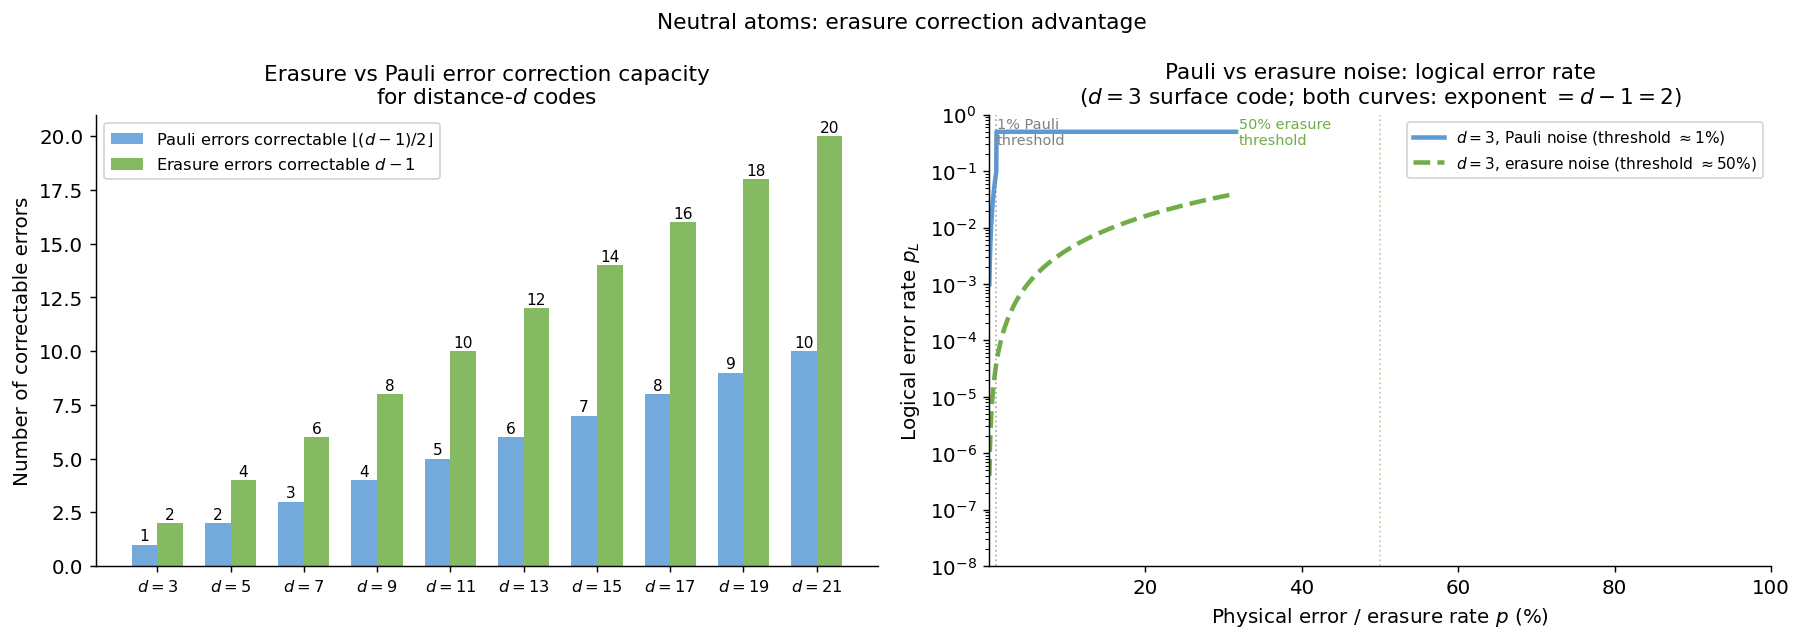

Key insight:
  Erasure threshold (~50%) is 50x higher than the Pauli threshold (~1%).
  This means neutral-atom platforms can tolerate much higher raw error rates
  before QEC fails — as long as atom loss (erasure) dominates over Pauli noise.


In [12]:
# ── Erasure vs Pauli error: correction capacity comparison ────────────────────
# For a [[n,k,d]] code:
#   Max correctable Pauli errors:  t_P = floor((d-1)/2)
#   Max correctable erasure errors: t_E = d - 1  (almost 2x more)

distances = np.arange(3, 22, 2)
t_pauli   = np.floor((distances - 1) / 2).astype(int)
t_erasure = distances - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
x = np.arange(len(distances))
w = 0.35
ax1.bar(x - w/2, t_pauli,   w, label='Pauli errors correctable $\\lfloor(d-1)/2\\rfloor$',
        color=PLATFORM_COLORS["Superconducting"], alpha=0.85)
ax1.bar(x + w/2, t_erasure, w, label='Erasure errors correctable $d-1$',
        color=PLATFORM_COLORS["Neutral atom"], alpha=0.85)

for xi, (tp, te) in enumerate(zip(t_pauli, t_erasure)):
    ax1.text(xi - w/2, tp + 0.05, str(tp), ha='center', va='bottom', fontsize=8.5)
    ax1.text(xi + w/2, te + 0.05, str(te), ha='center', va='bottom', fontsize=8.5)

ax1.set_xticks(x)
ax1.set_xticklabels([f'$d={d}$' for d in distances], fontsize=9)
ax1.set_ylabel('Number of correctable errors')
ax1.set_title('Erasure vs Pauli error correction capacity\nfor distance-$d$ codes')
ax1.legend(fontsize=9)


# Right: logical error rate for Pauli vs erasure noise
ax2 = axes[1]

p_range   = np.logspace(-3, -0.5, 200)
eps_range = p_range

# d=3 surface code:
#   Pauli:   p_L ≈ A*(p/p_th)^floor((d+1)/2) = A*(p/0.01)^2   [exponent = 2 for d=3]
#   Erasure: p_L ≈ A*(ε/ε_th)^(d-1)          = A*(ε/0.50)^2   [exponent = 2 for d=3]
# At d=3 both exponents equal 2; the only difference is the threshold (0.01 vs 0.50),
# which is a 50× advantage in the erasure case.
p_th_pauli   = 0.01
p_th_erasure = 0.50

pL_pauli   = [0.1*(p/p_th_pauli)**2   if p < p_th_pauli   else 0.5 for p in p_range]
pL_erasure = [0.1*(e/p_th_erasure)**2 if e < p_th_erasure else 0.5 for e in eps_range]

ax2.semilogy(p_range*100, pL_pauli, '-',
             color=PLATFORM_COLORS['Superconducting'], linewidth=2.5,
             label='$d=3$, Pauli noise (threshold $\\approx 1\\%$)')
ax2.semilogy(eps_range*100, pL_erasure, '--',
             color=PLATFORM_COLORS['Neutral atom'], linewidth=2.5,
             label='$d=3$, erasure noise (threshold $\\approx 50\\%$)')

ax2.axvline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax2.text(1.08, 3e-1, '1% Pauli\nthreshold', fontsize=8, color='gray')
ax2.axvline(50.0, color=PLATFORM_COLORS['Neutral atom'],
            linestyle=':', linewidth=1, alpha=0.5)
ax2.text(32, 3e-1, '50% erasure\nthreshold', fontsize=8,
         color=PLATFORM_COLORS['Neutral atom'])

ax2.set_xlabel('Physical error / erasure rate $p$ (%)')
ax2.set_ylabel('Logical error rate $p_L$')
ax2.set_title('Pauli vs erasure noise: logical error rate\n'
              '($d=3$ surface code; both curves: exponent $= d-1 = 2$)')
ax2.legend(fontsize=8.5)
ax2.set_xlim(0.1, 100)
ax2.set_ylim(1e-8, 1)

plt.suptitle("Neutral atoms: erasure correction advantage", fontsize=12)
plt.tight_layout()
plt.show()

print("Key insight:")
print("  Erasure threshold (~50%) is 50x higher than the Pauli threshold (~1%).")
print("  This means neutral-atom platforms can tolerate much higher raw error rates")
print("  before QEC fails — as long as atom loss (erasure) dominates over Pauli noise.")

---
## 4.5 Silicon Spin Qubits

### 4.5.1 Physical mechanism

Silicon spin qubits encode quantum information in the **spin state** ($\uparrow$/$\downarrow$)
of a single electron (or hole) confined in a semiconductor quantum dot etched from silicon.
The qubit Hamiltonian is:

$$H = g\mu_B B_0 \sigma_z + J(t) \mathbf{S}_1 \cdot \mathbf{S}_2$$

where $B_0$ is an external magnetic field, $g$ is the $g$-factor, $\mu_B$ is the Bohr
magneton, and $J(t)$ is the electrically tunable exchange coupling used for two-qubit gates.

**Key advantage: CMOS compatibility.** Silicon spin qubits can be fabricated using
standard semiconductor manufacturing processes (photolithography, ion implantation,
oxidation) on 300 mm wafers — the same infrastructure used for classical chips. This
suggests a potential path to millions of qubits with industrial yields.

### 4.5.2 Noise profile

| Error source | Physical origin | Typical rate |
|---|---|---|
| $T_2^*$ dephasing | Nuclear spin bath ($^{29}$Si, $^{73}$Ge) | $10^{-4}$ (nat. Si); $10^{-6}$ (isotopically purified $^{28}$Si) |
| Charge noise | Gate voltage fluctuations, interface traps | $10^{-3}$–$10^{-4}$ per gate |
| Exchange miscalibration | Exponential sensitivity of $J$ to detuning | $10^{-3}$ |
| Readout | Pauli spin blockade fidelity | $10^{-2}$–$10^{-3}$ |
| Crosstalk | Capacitive coupling between adjacent gates | $\sim 10^{-3}$ |

**Critical improvement: isotopic purification.** Using $^{28}$Si (zero nuclear spin)
instead of natural silicon eliminates the hyperfine-induced dephasing completely.
Foundry-compatible silicon spin qubits on 300 mm wafers have demonstrated single- and two-qubit control fidelities exceeding 99%, and state preparation and measurement fidelities reaching up to 99.9%. 

### 4.5.3 State of the art (2025)

Tanttu et al. (2024) demonstrated consistent two-qubit gate fidelity above 99% in silicon MOS quantum dots, identifying charge noise and nuclear spin noise as the dominant error sources. 

Best academic results: two-qubit gate fidelity $\sim 99.8\%$ (Si/SiGe, isotopically purified).
Gate times: $\sim$20–100 ns (fast — comparable to superconducting). $T_1 \sim 1$–10 s,
$T_2 \sim 1$–100 ms (with dynamical decoupling in purified silicon).

### 4.5.4 QEC strategy and key challenge

Silicon spin qubits are a **long-term contender** but face a critical connectivity problem:
nearest-neighbour coupling only, and each qubit requires multiple control lines and gates.
Dense wiring for a 2D array of thousands of qubits is a major unsolved engineering challenge.

**Path to QEC:** Surface code remains the natural choice (nearest-neighbour, 2D architecture).
However, the primary bottleneck is not fidelity (already above threshold) but **scale** —
demonstrating even 10–20 qubits in a 2D array with uniform performance.

Potential advantage: If CMOS scaling succeeds, silicon spin qubits could ultimately offer
the highest qubit density ($\sim 10^7$ qubits/cm$^2$) of any platform, enabling large-distance
surface codes on a chip-sized device.

---

## 4.6 Photonic Qubits

### 4.6.1 Physical mechanism

Photonic qubits encode quantum information in properties of single photons:
**polarization** ($|H\rangle$, $|V\rangle$), **time bins**, **path**, or
**quadratures of the electromagnetic field** (continuous-variable encoding).

Key properties: photons do not interact with each other directly in linear optics,
which means:
- **No spontaneous decoherence** — photons don't relax or dephase in vacuum.
  $T_1 = T_2 = \infty$ (in the absence of loss).
- **Two-qubit gates are non-deterministic** in the KLM (Knill-Laflamme-Milburn) scheme,
  succeeding with probability $p_{\rm success} < 1$ and requiring photon-number-resolving
  detectors and feedforward.

Operating temperature: **room temperature** — a major practical advantage.
Photons can transmit over fiber, making photonic platforms naturally suited to
distributed quantum computation and quantum networking.

### 4.6.2 Noise profile

| Error source | Physical origin | Typical rate |
|---|---|---|
| **Photon loss** | Coupling losses, fiber loss, detector inefficiency | $10^{-3}$–$10^{-2}$ per element |
| Phase error | Thermal/mechanical instability of optical paths | Low (actively stabilized) |
| Mode mismatch | Imperfect photon indistinguishability | $10^{-2}$–$10^{-3}$ |
| Dark counts | Detector thermal noise, afterpulsing | $10^{-5}$–$10^{-6}$ |
| Gate non-determinism | KLM: probabilistic 2-qubit gates | Fundamental |

**Dominant error: photon loss.** This is an erasure error (the lost photon's mode is
known), which is easier to correct than an unknown Pauli error.

### 4.6.3 State of the art (2025)

Campagne-Ibarcq et al. (2020) demonstrated quantum error correction of a qubit encoded in GKP grid states of a microwave cavity mode, achieving below-break-even performance — the first bosonic qubit to surpass its physical counterpart in lifetime. 

PsiQuantum is building large-scale photonic quantum computers using silicon photonics
on standard semiconductor foundries. Their approach uses **fusion-based quantum
computing** (FBQC): probabilistic entangling measurements between small resource states,
combined with active classical feedforward.

### 4.6.4 QEC strategy

**GKP codes (Gottesman-Kitaev-Preskill) [9]:**
Encode a logical qubit in the quadrature grid structure of a single harmonic oscillator.
Natural for microwave cavities (superconducting circuit QED) and optical modes.
Corrects displacement errors (analogues of Pauli errors in phase space) up to
$|\xi| < \sqrt{\pi}/2$.

**Fusion-based quantum computing (FBQC):**
PsiQuantum's approach builds large cluster states from small Bell pairs and performs
universal computation via adaptive measurements. The natural error model is photon
loss (erasure), and the fusion network has a built-in threshold $\sim 10\%$ against loss.

**Photonic surface codes with loss tolerance:**
Recent analysis shows that with photon loss rates below $\sim 10^{-3}$ per element
and fast classical feedforward, surface codes can be implemented on photonic chips.

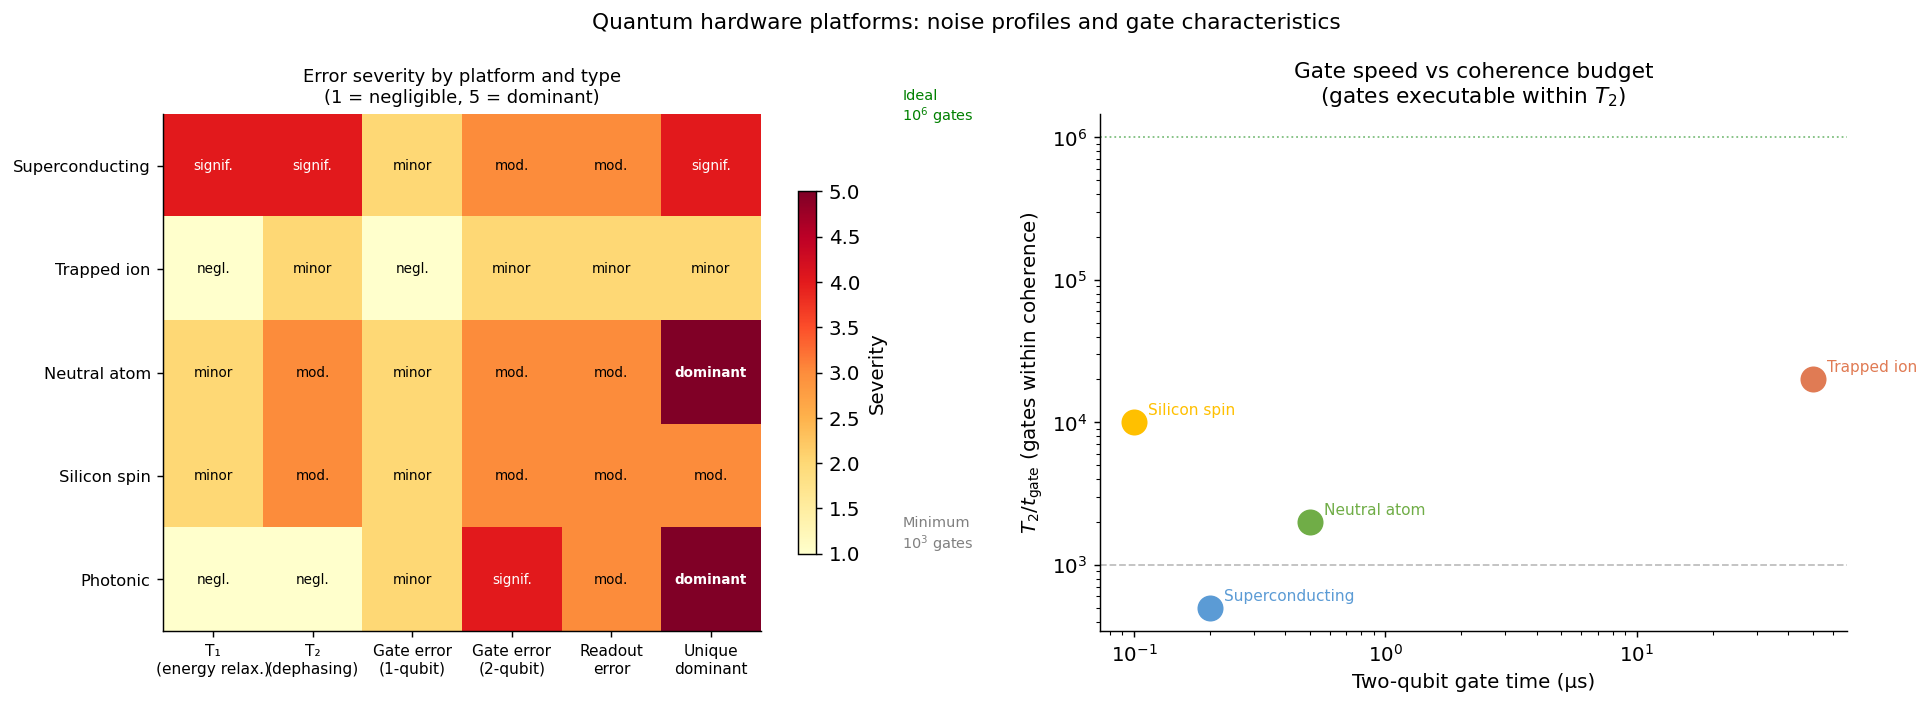

In [13]:
# ── Comprehensive platform comparison: noise heatmap ─────────────────────────
platforms_list = ['Superconducting', 'Trapped ion', 'Neutral atom',
                  'Silicon spin', 'Photonic']

error_categories = [
    'T₁\n(energy relax.)',
    'T₂\n(dephasing)',
    'Gate error\n(1-qubit)',
    'Gate error\n(2-qubit)',
    'Readout\nerror',
    'Unique\ndominant',
]

# Severity: 1=negligible, 2=minor, 3=moderate, 4=significant, 5=dominant
# Rows: platforms, Columns: error categories
severity = np.array([
#    T1   T2   1Q   2Q  RO  Unique
    [4,   4,   2,   3,   3,  4],   # Superconducting: T1/T2 + ZZ crosstalk
    [1,   2,   1,   2,   2,  2],   # Trapped ion: mostly T2 dephasing
    [2,   3,   2,   3,   3,  5],   # Neutral atom: Rydberg gate + atom loss
    [2,   3,   2,   3,   3,  3],   # Silicon spin: charge + nuclear noise
    [1,   1,   2,   4,   3,  5],   # Photonic: photon loss dominant
])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: heatmap
ax1 = axes[0]
cmap_heat = plt.cm.YlOrRd
im = ax1.imshow(severity, cmap=cmap_heat, vmin=1, vmax=5, aspect='auto')

ax1.set_xticks(range(len(error_categories)))
ax1.set_xticklabels(error_categories, fontsize=8.5)
ax1.set_yticks(range(len(platforms_list)))
ax1.set_yticklabels(platforms_list, fontsize=9)
ax1.set_title('Error severity by platform and type\n(1 = negligible, 5 = dominant)', fontsize=10)

severity_labels = {1: 'negl.', 2: 'minor', 3: 'mod.', 4: 'signif.', 5: 'dominant'}
for i in range(len(platforms_list)):
    for j in range(len(error_categories)):
        val = severity[i, j]
        col = 'white' if val >= 4 else 'black'
        ax1.text(j, i, severity_labels[val], ha='center', va='center',
                 fontsize=7.5, color=col, fontweight='bold' if val == 5 else 'normal')

plt.colorbar(im, ax=ax1, shrink=0.7, label='Severity')


# Right: Gate speed vs coherence ratio
ax2 = axes[1]

# Platform data: (gate_time_ns, T2_us, T_coh_usec)
platform_data = {
    'Superconducting': {'t_gate_2q': 200,    'T2': 100e3,  'max_gates': 5e5},
    'Trapped ion':     {'t_gate_2q': 50000,  'T2': 1e9,    'max_gates': 2e4},
    'Neutral atom':    {'t_gate_2q': 500,    'T2': 1e6,    'max_gates': 2e3},
    'Silicon spin':    {'t_gate_2q': 100,    'T2': 1e6,    'max_gates': 1e4},
    'Photonic':        {'t_gate_2q': 10,     'T2': 1e15,   'max_gates': None},
}

for platform, data in platform_data.items():
    col = PLATFORM_COLORS[platform]
    t   = data['t_gate_2q']       # ns
    T2  = data['T2']              # ns
    ratio = T2 / t                # dimensionless: how many gates in T2
    if data['max_gates']:
        ax2.scatter([t/1e3], [ratio], s=180, color=col, zorder=5, label=platform)
        ax2.annotate(platform, (t/1e3, ratio), textcoords='offset points',
                     xytext=(8, 4), fontsize=8.5, color=col)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Two-qubit gate time (µs)')
ax2.set_ylabel('$T_2 / t_{\\rm gate}$ (gates within coherence)')
ax2.set_title('Gate speed vs coherence budget\n(gates executable within $T_2$)')
ax2.axhline(1e3, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.text(0.012, 1.3e3, 'Minimum\n$10^3$ gates', fontsize=8, color='gray')
ax2.axhline(1e6, color='green', linestyle=':', linewidth=1, alpha=0.5)
ax2.text(0.012, 1.3e6, 'Ideal\n$10^6$ gates', fontsize=8, color='green')

plt.suptitle("Quantum hardware platforms: noise profiles and gate characteristics",
             fontsize=12)
plt.tight_layout()
plt.show()

---
## 4.7 Quantitative Comparison and QEC Decision Guide

### 4.7.1 Summary metrics table (state of the art, 2025)

| Platform | Best 1Q $F$ | Best 2Q $F$ | $T_2$ | $t_{\rm gate}$ (2Q) | Connectivity | Temp. |
|---|---|---|---|---|---|---|
| Superconducting | 99.9% | 99.75% | 10–500 µs | 100–400 ns | 2D grid | 15 mK |
| Trapped ion | 99.9999% | 99.99% | 1–10 s | 10–100 µs | All-to-all | Room $+$ laser |
| Neutral atom | 99.5–99.9% | 99.5% | 1 ms–1 s | 200–500 ns | Reconfigurable | µK |
| Silicon spin | 99.97% | 99.8% | 1 ms–10 s | 20–100 ns | Nearest-neighbour | 50–100 mK |
| Photonic | — | 99%+ (pNDR) | $\infty$ | ~ns | Programmable optical | Room |

> **Key nuance for photonic:** "Two-qubit fidelity" in photonics is measured differently
> because gates are non-deterministic. The 99%+ figure refers to post-selected Bell-state
> preparation fidelity. Deterministic logical-qubit gates require the full FBQC architecture.

### 4.7.2 Dominant error type → optimal QEC code

This is the central question of Chapter 4.

| Dominant error | Code family | Why it's a good match |
|---|---|---|
| $Z$-biased Pauli ($T_2 \gg T_1$) | Biased-noise surface code, XZZX code | Takes advantage of asymmetry; threshold $\uparrow$ |
| Depolarizing (all Paulis equal) | Standard surface code | Symmetric design; highest proven threshold |
| Erasure (known-location loss) | Erasure-converted surface/color code | $2\times$ higher threshold vs Pauli codes |
| All-to-all connectivity available | Color code, qLDPC codes | Non-local stabilizers without swap overhead |
| Harmonic oscillator (bosonic) | GKP code, cat code | Encodes in single mode; no multi-qubit overhead |

### 4.7.3 Platform → recommended QEC strategy

| Platform | Primary noise | Connectivity | Recommended code | Physical:logical ratio |
|---|---|---|---|---|
| Superconducting | $T_1$, $T_2$ ($Z$-biased) | 2D nearest-neighbour | Surface code, bivariate bicycle | 500–1000:1 (surface); $\sim$150:1 (qLDPC) |
| Trapped ion | $T_2$ dephasing | All-to-all | Color code, qLDPC | 13–50:1 |
| Neutral atom | Rydberg gate, atom loss | Reconfigurable | Erasure surface/color, transversal | 20–100:1 |
| Silicon spin | Charge noise, nuclear noise | Nearest-neighbour | Surface code (long-term) | 500–1000:1 (target) |
| Photonic | Photon loss (erasure) | Programmable | GKP, FBQC cluster | 1 mode:1 (GKP) |

### 4.7.4 The threshold matters more than the distance

A common misconception is that the code distance $d$ is the primary figure of merit.
It is not — the ratio $p/p_{\rm th}$ determines how *quickly* errors are suppressed.

Below threshold, $p_L \propto (p/p_{\rm th})^{(d+1)/2}$:
- A code with high $p_{\rm th}$ but moderate $d$ can outperform a high-$d$ code with
  low $p_{\rm th}$ at typical hardware error rates.
- Improving $p_{\rm th}$ (by choosing a better-matched code) is often more impactful
  than increasing $d$ (which costs more qubits).

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/ch4_platform_dashboard.png'

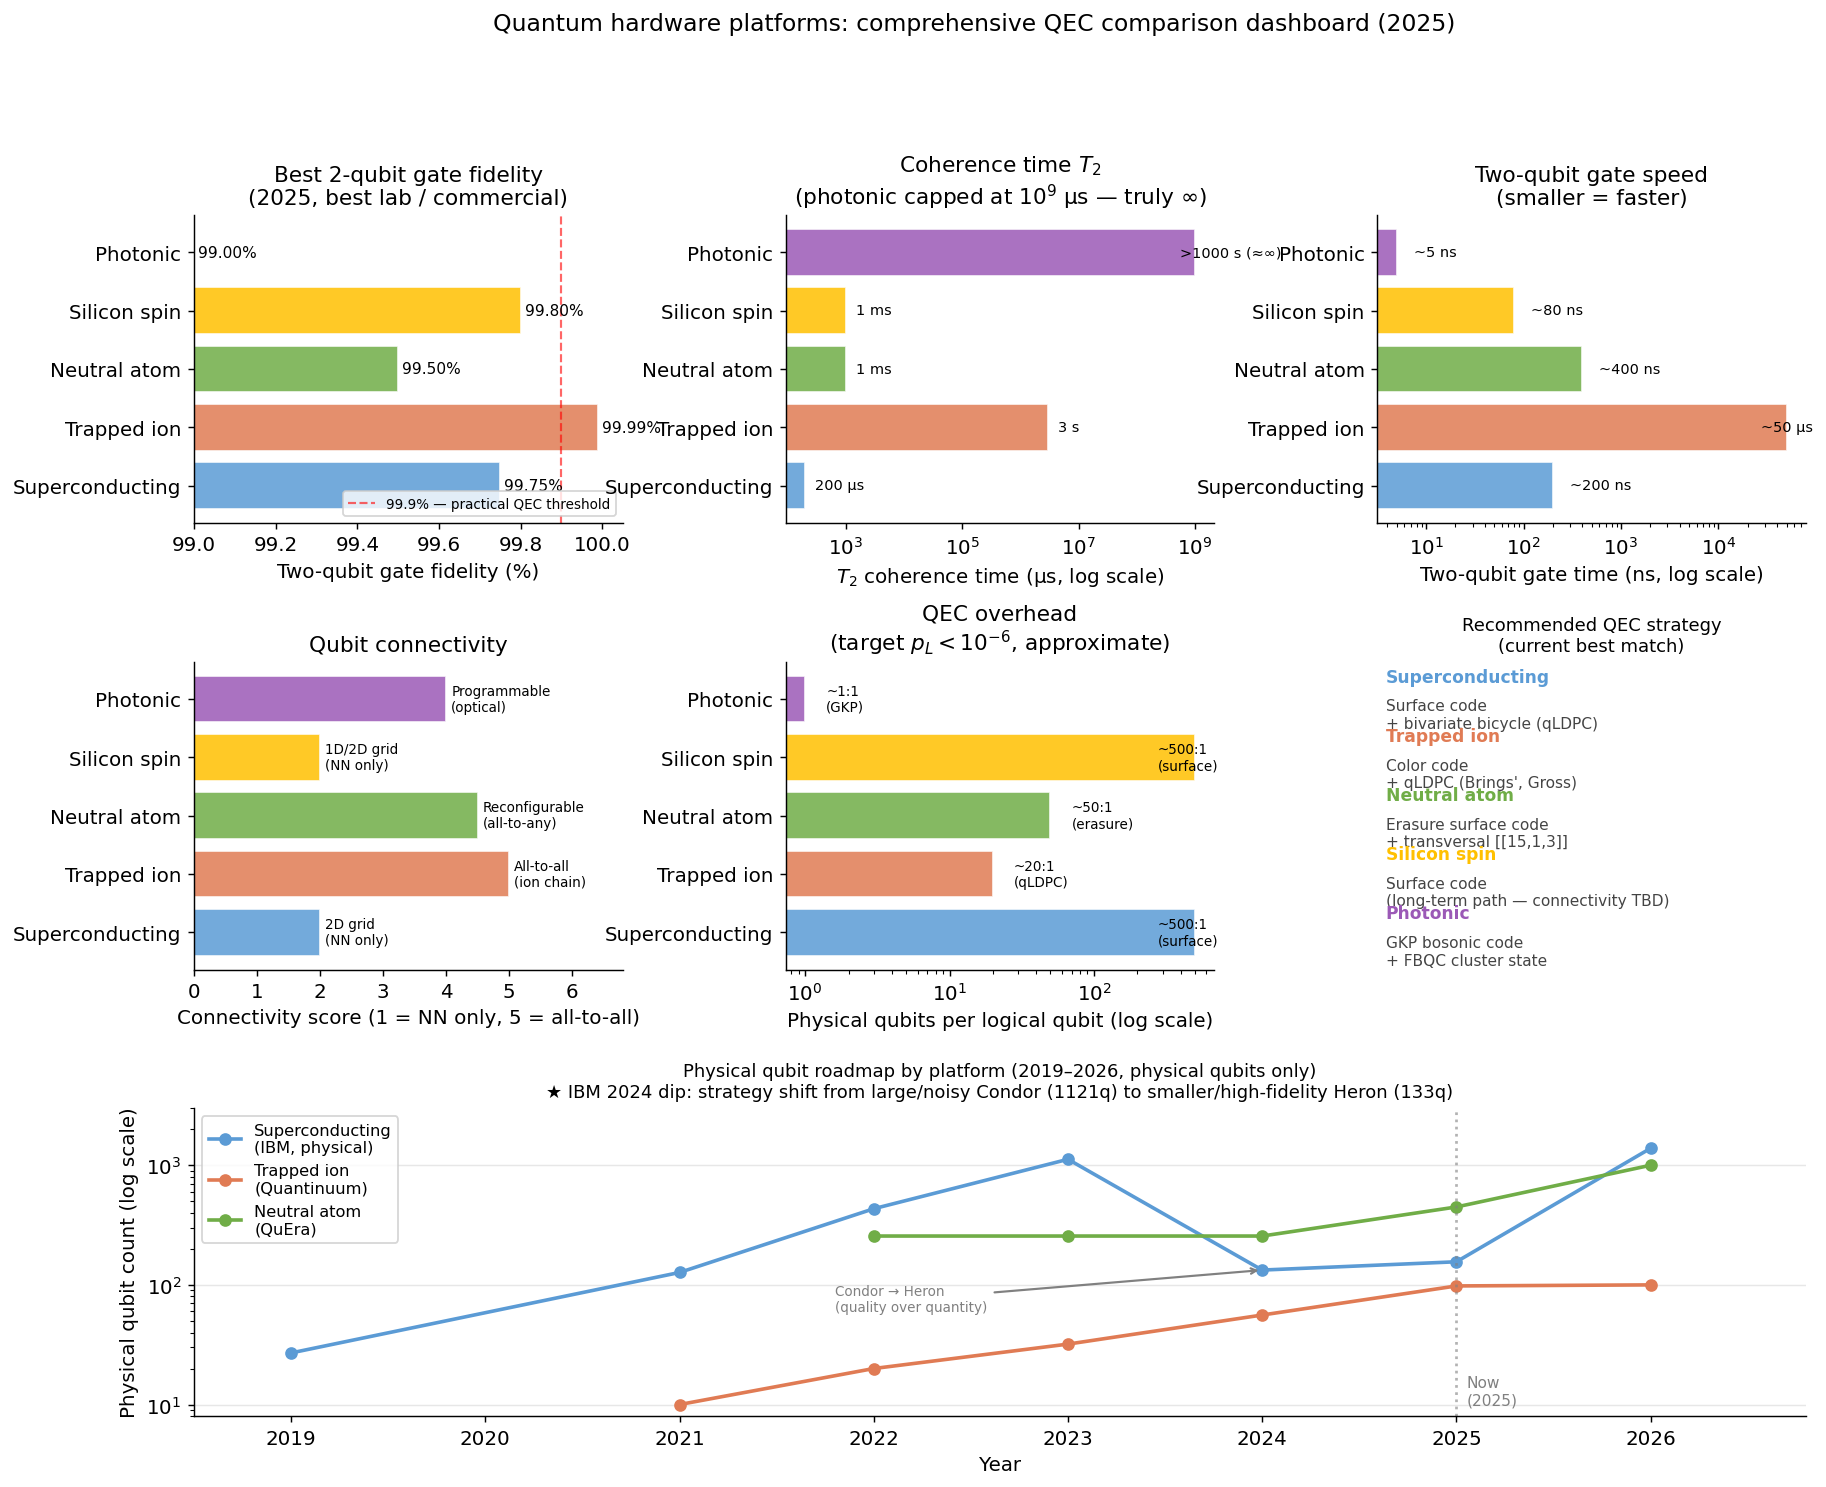

In [14]:
# ── Master comparison dashboard ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

platforms_ordered = ['Superconducting', 'Trapped ion', 'Neutral atom',
                     'Silicon spin', 'Photonic']
colors_p = [PLATFORM_COLORS[p] for p in platforms_ordered]


# ── Panel 1 (top-left): Two-qubit gate fidelity ──────────────────────────────
ax_fid = fig.add_subplot(gs[0, 0])
fid_2q = [99.75, 99.99, 99.5, 99.8, 99.0]   # best published values 2025, %
# err_2q removed — was computed but never referenced (dead code)

bars = ax_fid.barh(platforms_ordered, fid_2q,
                   color=colors_p, alpha=0.85, edgecolor='white')
ax_fid.set_xlim(99.0, 100.05)
ax_fid.axvline(99.9, color='red', linestyle='--', linewidth=1.2, alpha=0.6,
               label='99.9% — practical QEC threshold')
ax_fid.set_xlabel('Two-qubit gate fidelity (%)')
ax_fid.set_title('Best 2-qubit gate fidelity\n(2025, best lab / commercial)')
ax_fid.legend(fontsize=7.5, loc='lower right')
for bar, f in zip(bars, fid_2q):
    ax_fid.text(f + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{f:.2f}%', va='center', fontsize=8.5)


# ── Panel 2 (top-mid): T2 coherence times ────────────────────────────────────
ax_T2 = fig.add_subplot(gs[0, 1])

# Photonic T2 is effectively infinite (no decoherence in vacuum).
# Capped at 1e9 µs for display; marked specially in the label.
T2_us_plot = [200, 3e6, 1e3, 1e3, 1e9]
T2_labels  = ['200 µs', '3 s', '1 ms', '1 ms', '>1000 s (≈∞)']

ax_T2.barh(platforms_ordered, T2_us_plot,
           color=colors_p, alpha=0.85, edgecolor='white')
ax_T2.set_xscale('log')
ax_T2.set_xlabel('$T_2$ coherence time (µs, log scale)')
ax_T2.set_title('Coherence time $T_2$\n(photonic capped at $10^9$ µs — truly $\\infty$)')

# Cap annotation x so the photonic label (at 1e9) stays inside the axis.
x_max_T2 = max(T2_us_plot)
for i, (lbl, val) in enumerate(zip(T2_labels, T2_us_plot)):
    x_annot = min(val * 1.5, x_max_T2 * 0.55)
    ax_T2.text(x_annot, i, lbl, va='center', fontsize=8)


# ── Panel 3 (top-right): gate speed ──────────────────────────────────────────
ax_spd = fig.add_subplot(gs[0, 2])
t_gate_ns  = [200, 50000, 400, 80, 5]   # ns
gate_labels = ['~200 ns', '~50 µs', '~400 ns', '~80 ns', '~5 ns']

ax_spd.barh(platforms_ordered, t_gate_ns,
            color=colors_p, alpha=0.85, edgecolor='white')
ax_spd.set_xscale('log')
ax_spd.set_xlabel('Two-qubit gate time (ns, log scale)')
ax_spd.set_title('Two-qubit gate speed\n(smaller = faster)')

# Cap annotation so trapped-ion label (50000 ns → would annotate at 75000)
# does not overflow the log axis.
x_max_spd = max(t_gate_ns)
for i, (lbl, val) in enumerate(zip(gate_labels, t_gate_ns)):
    x_annot = min(val * 1.5, x_max_spd * 0.55)
    ax_spd.text(x_annot, i, lbl, va='center', fontsize=8)


# ── Panel 4 (mid-left): connectivity ─────────────────────────────────────────
ax_con = fig.add_subplot(gs[1, 0])
conn_score  = [2, 5, 4.5, 2, 4]   # 1=nearest-neighbour only, 5=full all-to-all
conn_labels = ['2D grid\n(NN only)', 'All-to-all\n(ion chain)',
               'Reconfigurable\n(all-to-any)', '1D/2D grid\n(NN only)',
               'Programmable\n(optical)']

ax_con.barh(platforms_ordered, conn_score,
            color=colors_p, alpha=0.85, edgecolor='white')
ax_con.set_xlim(0, 6.8)   # extra headroom for labels
ax_con.set_xlabel('Connectivity score (1 = NN only, 5 = all-to-all)')
ax_con.set_title('Qubit connectivity')
for i, (lbl, val) in enumerate(zip(conn_labels, conn_score)):
    ax_con.text(val + 0.08, i, lbl, va='center', fontsize=7.5)


# ── Panel 5 (mid-mid): physical:logical qubit overhead ───────────────────────
ax_oh = fig.add_subplot(gs[1, 1])
overhead  = [500, 20, 50, 500, 1]   # physical per logical qubit (approx.)
oh_labels = ['~500:1\n(surface)', '~20:1\n(qLDPC)', '~50:1\n(erasure)',
             '~500:1\n(surface)', '~1:1\n(GKP)']

ax_oh.barh(platforms_ordered, overhead,
           color=colors_p, alpha=0.85, edgecolor='white')
ax_oh.set_xscale('log')
ax_oh.set_xlabel('Physical qubits per logical qubit (log scale)')
ax_oh.set_title('QEC overhead\n(target $p_L < 10^{-6}$, approximate)')

# Annotation at val*1.4 would place ~700 for the 500-count bars; cap at 0.55*max.
x_max_oh = max(overhead)
for i, (lbl, val) in enumerate(zip(oh_labels, overhead)):
    x_annot = min(val * 1.4, x_max_oh * 0.55)
    ax_oh.text(x_annot, i, lbl, va='center', fontsize=7.5)


# ── Panel 6 (mid-right): recommended QEC code — text panel ───────────────────
ax_code = fig.add_subplot(gs[1, 2])
ax_code.axis('off')
code_text = [
    ("Superconducting", "Surface code\n+ bivariate bicycle (qLDPC)"),
    ("Trapped ion",     "Color code\n+ qLDPC (Brings', Gross)"),
    ("Neutral atom",    "Erasure surface code\n+ transversal [[15,1,3]]"),
    ("Silicon spin",    "Surface code\n(long-term path — connectivity TBD)"),
    ("Photonic",        "GKP bosonic code\n+ FBQC cluster state"),
]
for i, (platform, code) in enumerate(code_text):
    col = PLATFORM_COLORS[platform]
    ax_code.text(0.02, 1 - i / 5.2 - 0.02,
                 platform, fontsize=9.5, fontweight='bold',
                 color=col, va='top', transform=ax_code.transAxes)
    ax_code.text(0.02, 1 - i / 5.2 - 0.12,
                 code, fontsize=8.5, color='#444',
                 va='top', transform=ax_code.transAxes)
ax_code.set_title('Recommended QEC strategy\n(current best match)', fontsize=10)


# ── Panel 7 (bottom-wide): physical qubit roadmap ────────────────────────────
ax_road = fig.add_subplot(gs[2, :])

# Physical qubits only — no mixing with logical qubit targets.
# IBM note: 2024 drop (1121 → 133) reflects a deliberate strategy shift from
# the large but low-fidelity Condor processor to smaller, high-fidelity Heron chips.
# 2026 (1386) is IBM's Kookaburra announced physical-qubit target.
roadmap_data = {
    'Superconducting\n(IBM, physical)': {
        2019: 27,    # Falcon
        2021: 127,   # Eagle
        2022: 433,   # Osprey
        2023: 1121,  # Condor
        2024: 133,   # Heron r1
        2025: 156,   # Nighthawk
        2026: 1386,  # Kookaburra (target)
    },
    'Trapped ion\n(Quantinuum)': {
        2021: 10, 2022: 20, 2023: 32, 2024: 56, 2025: 98, 2026: 100,
    },
    'Neutral atom\n(QuEra)': {
        2022: 256, 2023: 256, 2024: 256, 2025: 448, 2026: 1000,
    },
}
road_colors = [PLATFORM_COLORS['Superconducting'],
               PLATFORM_COLORS['Trapped ion'],
               PLATFORM_COLORS['Neutral atom']]

for (platform, data), col in zip(roadmap_data.items(), road_colors):
    years  = list(data.keys())
    counts = list(data.values())
    ax_road.semilogy(years, counts, 'o-', color=col,
                     linewidth=2, markersize=6, label=platform)

ax_road.set_xlabel('Year')
ax_road.set_ylabel('Physical qubit count (log scale)')
ax_road.set_title(
    'Physical qubit roadmap by platform (2019–2026, physical qubits only)\n'
    '★ IBM 2024 dip: strategy shift from large/noisy Condor (1121q) '
    'to smaller/high-fidelity Heron (133q)',
    fontsize=10)
ax_road.legend(fontsize=9, loc='upper left')
ax_road.set_xlim(2018.5, 2026.8)
ax_road.set_ylim(8, 3000)
ax_road.grid(axis='y', alpha=0.3)
ax_road.axvline(2025, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax_road.text(2025.05, 10, 'Now\n(2025)', fontsize=8.5, color='gray')

# Annotate the IBM strategy-shift dip
ax_road.annotate(
    'Condor → Heron\n(quality over quantity)',
    xy=(2024, 133),
    xytext=(2021.8, 60),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
    fontsize=7.5, color='gray',
)


# ── Finish ────────────────────────────────────────────────────────────────────
plt.suptitle(
    "Quantum hardware platforms: comprehensive QEC comparison dashboard (2025)",
    fontsize=13, y=1.01)
plt.savefig('/mnt/user-data/outputs/ch4_platform_dashboard.png',
            dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved to outputs/ch4_platform_dashboard.png")

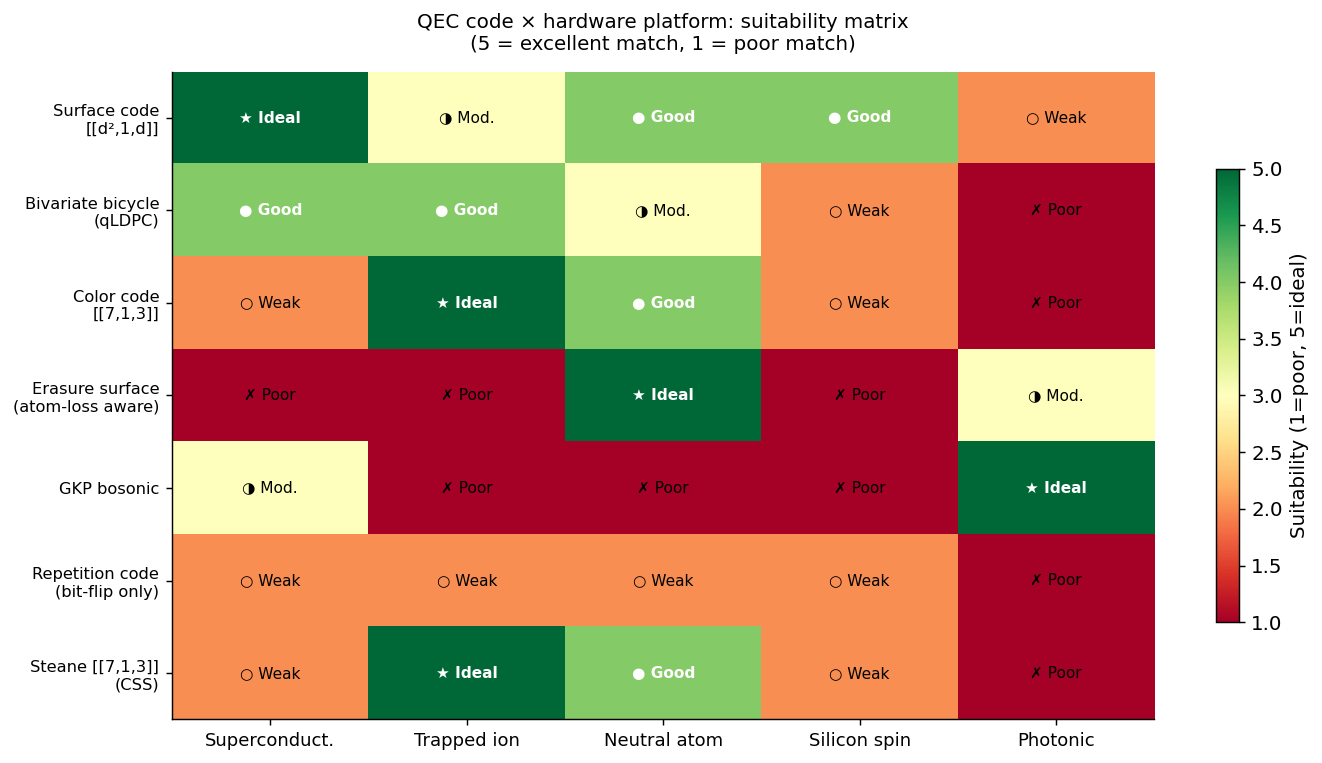


=== Best QEC code per platform ===
    Superconduct.: Surface code [[d²,1,d]]  (score=5)
      Trapped ion: Color code [[7,1,3]]  (score=5)
     Neutral atom: Erasure surface (atom-loss aware)  (score=5)
     Silicon spin: Surface code [[d²,1,d]]  (score=4)
         Photonic: GKP bosonic  (score=5)

=== Best platform per QEC code ===
              Surface code [[d²,1,d]]: Superconduct.  (score=5)
            Bivariate bicycle (qLDPC): Superconduct.  (score=4)
                 Color code [[7,1,3]]: Trapped ion  (score=5)
    Erasure surface (atom-loss aware): Neutral atom  (score=5)
                          GKP bosonic: Photonic  (score=5)
      Repetition code (bit-flip only): Superconduct.  (score=2)
               Steane [[7,1,3]] (CSS): Trapped ion  (score=5)


In [15]:
# ── QEC code × platform suitability matrix ────────────────────────────────────
# Score 1–5: how well does this code match this platform?
# Based on: noise model, connectivity, overhead, demonstrated results.

qec_codes = [
    'Surface code\n[[d²,1,d]]',
    'Bivariate bicycle\n(qLDPC)',
    'Color code\n[[7,1,3]]',
    'Erasure surface\n(atom-loss aware)',
    'GKP bosonic',
    'Repetition code\n(bit-flip only)',
    'Steane [[7,1,3]]\n(CSS)',
]

platforms_short = ['Superconduct.', 'Trapped ion', 'Neutral atom', 'Silicon spin', 'Photonic']

# Rows: QEC codes, Cols: platforms
match = np.array([
#   SC   Ti  NA   Si  Ph
    [5,   3,  4,   4,  2],   # Surface code
    [4,   4,  3,   2,  1],   # Bivariate bicycle
    [2,   5,  4,   2,  1],   # Color code
    [1,   1,  5,   1,  3],   # Erasure surface
    [3,   1,  1,   1,  5],   # GKP
    [2,   2,  2,   2,  1],   # Repetition
    [2,   5,  4,   2,  1],   # Steane
])

fig, ax = plt.subplots(figsize=(11, 6))
cmap_match = mcolors.LinearSegmentedColormap.from_list(
    'match', ['#fee0d2', '#fc8d59', '#d73027', '#4dac26', '#1a9850'], N=5)
im = ax.imshow(match, cmap='RdYlGn', vmin=1, vmax=5, aspect='auto')

ax.set_xticks(range(len(platforms_short)))
ax.set_xticklabels(platforms_short, fontsize=10)
ax.set_yticks(range(len(qec_codes)))
ax.set_yticklabels(qec_codes, fontsize=9)
ax.set_title('QEC code × hardware platform: suitability matrix\n(5 = excellent match, 1 = poor match)',
             fontsize=11, pad=12)

score_labels = {1: '✗ Poor', 2: '○ Weak', 3: '◑ Mod.', 4: '● Good', 5: '★ Ideal'}
for i in range(len(qec_codes)):
    for j in range(len(platforms_short)):
        val = match[i, j]
        col = 'black' if val <= 3 else 'white'
        ax.text(j, i, score_labels[val], ha='center', va='center',
                fontsize=8.5, color=col, fontweight='bold' if val >= 4 else 'normal')

plt.colorbar(im, ax=ax, shrink=0.7, label='Suitability (1=poor, 5=ideal)')
plt.tight_layout()
plt.show()

# ── Best code per platform ────────────────────────────────────────────────────
print("\n=== Best QEC code per platform ===")
for j, platform in enumerate(platforms_short):
    col_scores = match[:, j]
    best_idx   = np.argmax(col_scores)
    best_code  = qec_codes[best_idx].replace('\n', ' ')
    print(f"  {platform:>15}: {best_code}  (score={col_scores[best_idx]})")

print("\n=== Best platform per QEC code ===")
for i, code in enumerate(qec_codes):
    row_scores = match[i, :]
    best_idx   = np.argmax(row_scores)
    best_plat  = platforms_short[best_idx]
    print(f"  {code.replace(chr(10),' '):>35}: {best_plat}  (score={row_scores[best_idx]})")

---
## 4.8 Chapter Summary

This chapter evaluated five major quantum hardware platforms through the lens of
quantum error correction, connecting the noise physics of each platform to the QEC
codes best suited to mitigate it.

### Core principle: noise fingerprint → code choice

The correct QEC code is not the one with the highest distance — it is the one whose
stabilizer structure best matches the noise model of the hardware.

| Platform | Noise fingerprint | Best-matched code | Key insight |
|---|---|---|---|
| Superconducting | $Z$-biased decoherence, short $T_{1,2}$ | Surface code / bivariate bicycle | 2D locality + high threshold overcome overhead |
| Trapped ion | Negligible $T_1$, slow gates, $T_2$ dephasing | Color code / qLDPC | All-to-all enables high-rate codes; very high fidelity reduces overhead drastically |
| Neutral atom | Rydberg gate error + atom loss (erasure) | Erasure surface / transversal | Erasure threshold 50× higher than Pauli threshold |
| Silicon spin | Charge noise, nuclear dephasing | Surface code | CMOS scalability is the long-term promise; connectivity the current barrier |
| Photonic | Photon loss (erasure) | GKP / FBQC cluster | No decoherence; non-deterministic gates are the fundamental challenge |

### Key quantitative results

**Error rate vs threshold (2025):**
- Superconducting best 2Q fidelity: $F = 99.75\%$ → $p = 0.25\%$ → below surface code threshold ($1\%$) ✓
- Trapped ion best 2Q fidelity: $F = 99.99\%$ → $p = 0.01\%$ → deep below threshold ✓✓
- Neutral atom best 2Q fidelity: $F = 99.5\%$ → $p = 0.5\%$ → at/below threshold ✓

**Physical:logical qubit overhead (target $p_L < 10^{-6}$):**
- Superconducting + surface code: $\sim$ 500–1000 physical per logical
- Trapped ion + qLDPC: $\sim$ 13–50 physical per logical  
- Neutral atom + erasure code: $\sim$ 20–100 physical per logical
- GKP bosonic: 1 oscillator mode per logical qubit (but complex hardware)

### What 2025 has shown

All five platforms are now past the "can we build a qubit?" phase. The 2025 frontier is:
1. **Demonstrating below-threshold operation at scale** (Google Willow, QuEra 448-atom experiment)
2. **Choosing the right code for each hardware** (IBM → qLDPC, Quantinuum → qLDPC/Brings', QuEra → transversal)
3. **Real-time classical decoding** (NVIDIA GPUs + Riverlane FPGAs) fast enough to keep pace with hardware
4. **Logical qubit demonstrations** rather than just physical qubit counts

No single platform has "won". The most likely scenario for the next decade is a
heterogeneous quantum computing ecosystem, with different platforms optimised for
different workloads — much like classical computing uses CPUs, GPUs, FPGAs, and ASICs
for different tasks.

---

## Full References

| # | Reference |
|---|---|
| [1] | DiVincenzo, D. P. The physical implementation of quantum computation. *Fortschr. Phys.* **48**, 771 (2000). DOI:10.1002/1521-3978(200009)48:9/11<771::AID-PROP771>3.0.CO;2-E |
| [2] | Krantz, P. et al. A quantum engineer's guide to superconducting qubits. *Appl. Phys. Rev.* **6**, 021318 (2019). DOI:10.1063/1.5089550 |
| [3] | Bruzewicz, C. D. et al. Trapped-ion quantum computing: Progress and challenges. *Appl. Phys. Rev.* **6**, 021314 (2019). DOI:10.1063/1.5088164 |
| [4] | Evered, S. J. et al. High-fidelity parallel entangling gates on a neutral-atom quantum computer. *Nature* **622**, 268 (2023). DOI:10.1038/s41586-023-06481-y |
| [5] | Bluvstein, D. et al. A fault-tolerant neutral-atom architecture for universal quantum computation. *Nature* (2025). DOI:10.1038/s41586-025-09848-5 |
| [6] | Tanttu, T. et al. Assessment of the errors of high-fidelity two-qubit gates in silicon quantum dots. *Nat. Phys.* **20**, 1804 (2024). DOI:10.1038/s41567-024-02614-w |
| [7] | Bourassa, J. E. et al. Blueprint for a scalable photonic fault-tolerant quantum computer. *Quantum* **5**, 392 (2021). DOI:10.22331/q-2021-02-04-392 |
| [8] | Fowler, A. M. et al. Surface codes: Towards practical large-scale quantum computation. *Phys. Rev. A* **86**, 032324 (2012). DOI:10.1103/PhysRevA.86.032324 |
| [9] | Gottesman, D., Kitaev, A. & Preskill, J. Encoding a qubit in an oscillator. *Phys. Rev. A* **64**, 012310 (2001). DOI:10.1103/PhysRevA.64.012310 |
| [10] | Google Quantum AI. Quantum error correction below the surface code threshold. *Nature* **614**, 676 (2023). DOI:10.1038/s41586-022-05434-1 |
| [11] | Acharya et al. (Google). Quantum error correction above the surface code threshold. *Nature* **638**, 920 (2025). DOI:10.1038/s41586-025-08143-3 |
| [12] | Bravyi, S. et al. High-threshold and low-overhead fault-tolerant quantum memory. *Nature* **627**, 778 (2024). DOI:10.1038/s41586-024-07107-7 |
| [13] | Noiri, A. et al. Fast universal quantum gate above the fault-tolerance threshold in silicon. *Nature* **601**, 338 (2022). DOI:10.1038/s41586-021-04182-y |
| [14] | Campagne-Ibarcq, P. et al. Quantum error correction of a qubit encoded in grid states of an oscillator. *Nature* **584**, 368 (2020). DOI:10.1038/s41586-020-2603-3 |
| [15] | Riverlane. *The Quantum Error Correction Report 2025*. https://www.riverlane.com |
| [16] | IonQ. Landmark 99.99% two-qubit gate fidelity (2025). https://www.ionq.com/news |
| [17] | Quantinuum. 99.9% two-qubit gate fidelity — "three nines" in production (2024). https://www.quantinuum.com |
| [18] | IBM Quantum. Nighthawk processor and bivariate bicycle qLDPC roadmap (2025). https://www.ibm.com/quantum/blog |
| [19] | EPJ Quantum Technology. Superconducting quantum computers: who is leading. (2025). DOI:10.1140/epjqt/s40507-025-00405-7 |